In [1]:
import pyttb as ttb
import numpy as np

import goated.utils.exo as ex
import goated.utils.scalers as sc
import goated.goals.physics as goals

import goated.rol_interface.models as rolm
from goated.cp import GocchaObjective, CPGoals

In [2]:
# Exodus file name with tensor data
fname = '../goated/examples/small.exo'

do_goal_plots = True  # construct goal plots
save_data = False     # save tensor reconstructions to disk
save_figs = False     # save figures
rank = 7              # Rank of the CP decomposition

In [3]:
# Read tensor from exodus file
exo = ex.ExoInfo()
exo.read_sheet(fname)
time = exo.t
num_time = len(time)

In [4]:
# Some global parameters
vars = [0,1,3,4,6,7,9]       # Exclude BZ, R, RHO_UZ, and U
B_var_ind = [0,1]            # variable indices for magnetic field
rho_var_ind = [2]            # variable index for density
mom_var_ind = [4,5]          # variables for momentum goal
T_var_ind = [6]              # variable index for temperature
tot_var_ind = B_var_ind+rho_var_ind+mom_var_ind+T_var_ind
int_var_ind = rho_var_ind+T_var_ind
kin_var_ind = rho_var_ind+mom_var_ind
mom_time_ind = range(1,num_time)    # time steps for momenum goal (exclude first few)
energy_time_ind = range(0,num_time) # time steps for energy goals

# select subset of variables
X = ttb.tensor(exo.tensor_data[:,:,vars,:])
sz = X.shape
var_labels = [exo.var_name[v] for v in vars]

In [5]:
# scale tensor values so that each variable has roughly the same order of magnitude
scaler = sc.StdScaler(X,exo.var_mode)
Xs = scaler.scale_tensor(X)
np.random.seed(1997)
us0,_,_ = ttb.cp_als(Xs,rank=rank,maxiters=50)
U0 = scaler.unscale_tensor(us0.full())
fit0 = 1-(X-U0).norm()/X.norm()

CP_ALS:
 Iter 0: f = 3.918725e-01 f-delta = 3.9e-01
 Iter 1: f = 5.592000e-01 f-delta = 1.7e-01
 Iter 2: f = 6.104830e-01 f-delta = 5.1e-02
 Iter 3: f = 6.464855e-01 f-delta = 3.6e-02
 Iter 4: f = 6.787011e-01 f-delta = 3.2e-02
 Iter 5: f = 7.079541e-01 f-delta = 2.9e-02
 Iter 6: f = 7.266493e-01 f-delta = 1.9e-02
 Iter 7: f = 7.381221e-01 f-delta = 1.1e-02
 Iter 8: f = 7.456901e-01 f-delta = 7.6e-03
 Iter 9: f = 7.513620e-01 f-delta = 5.7e-03
 Iter 10: f = 7.558476e-01 f-delta = 4.5e-03
 Iter 11: f = 7.593249e-01 f-delta = 3.5e-03
 Iter 12: f = 7.619163e-01 f-delta = 2.6e-03
 Iter 13: f = 7.637939e-01 f-delta = 1.9e-03
 Iter 14: f = 7.651447e-01 f-delta = 1.4e-03
 Iter 15: f = 7.661290e-01 f-delta = 9.8e-04
 Iter 16: f = 7.668656e-01 f-delta = 7.4e-04
 Iter 17: f = 7.674350e-01 f-delta = 5.7e-04
 Iter 18: f = 7.678889e-01 f-delta = 4.5e-04
 Iter 19: f = 7.682592e-01 f-delta = 3.7e-04
 Iter 20: f = 7.685659e-01 f-delta = 3.1e-04
 Iter 21: f = 7.688214e-01 f-delta = 2.6e-04
 Iter 22: f 

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


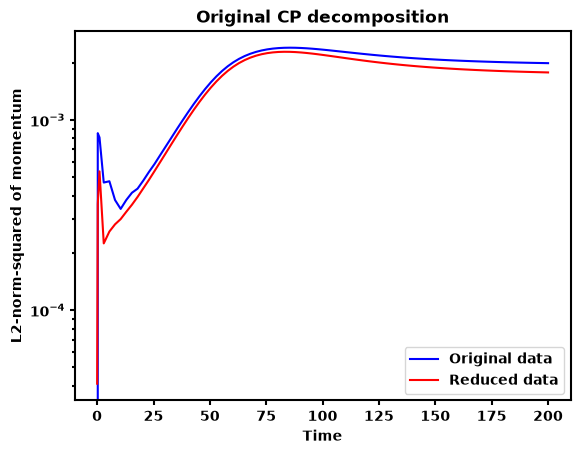

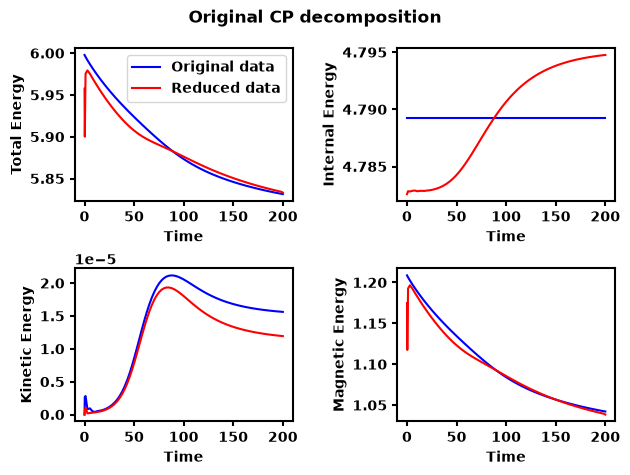

In [6]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us0,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Original CP decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('mom-initial.png')

    fig,axs = goals.plot_energies(X,us0,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Original CP decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('energy-initial.png')

In [7]:
mom_goal = goals.MomentumGoal(X,mom_var_ind,mom_time_ind,exo)
E_goal = goals.TotalEnergyGoal(X,tot_var_ind,energy_time_ind,exo)
T_goal = goals.InternalEnergyGoal(X,int_var_ind,energy_time_ind,exo)
P_goal = goals.KineticEnergyGoal(X,kin_var_ind,energy_time_ind,exo)
B_goal = goals.MagneticEnergyGoal(X,B_var_ind,energy_time_ind,exo)

mom_goal0 = mom_goal.computeScalar(U0)
E_goal0 = E_goal.computeScalar(U0)
T_goal0 = T_goal.computeScalar(U0)
P_goal0 = P_goal.computeScalar(U0)
B_goal0 = B_goal.computeScalar(U0)

print(f'Initial fit = {fit0:.4f},\nmomentum goal = {mom_goal0:.2e},\ntotal energy goal = {E_goal0:.2e},\ninternal energy goal = {T_goal0:.2e},\nkinetic energy goal {P_goal0:.2e},\nmagnetic energy goal = {B_goal0:.2e}')

Initial fit = 0.9948,
momentum goal = 2.24e-06,
total energy goal = 1.82e-02,
internal energy goal = 1.77e-03,
kinetic energy goal 5.27e-10,
magnetic energy goal = 1.21e-02


In [8]:
# Disable pyttb warnings about copy
import logging
logging.getLogger("root").setLevel(logging.ERROR)

my_goals = [mom_goal,T_goal,P_goal,B_goal]
ng = len(my_goals)+1
weights = [1/(ng*mom_goal0),1/(ng*T_goal0),1/(ng*P_goal0),1/(ng*B_goal0)]
goal = CPGoals(scaler, my_goals, weights)
a = 1/(ng*((Xs-us0.full()).norm()**2))
goccha = GocchaObjective(Xs, goal, a, 1.0)
_ = us0.normalize(weight_factor='all')

precondition = True
rol_params = rolm.build_parameter_list(status_test_iter_limit=5)
problem = rolm.GoatedRolModel(goccha, us0)
problem.solve(rol_params, precondition=precondition)



Truncated CG Trust-Region Solver
  iter  value          gnorm          snorm          delta          #fval     #grad     tr_flag   iterCG    flagCG    
  0     1.000000e+00   1.952726e+01   ---            1.000000e+01   1         1         ---       ---       ---       
  1     5.074729e-01   4.927401e+00   1.000000e+01   2.500000e+01   2         2         0         3         3         
  2     2.269422e-01   1.018173e+00   2.500000e+01   6.250000e+01   3         3         0         8         3         
  3     2.073915e-01   4.987695e-01   6.250000e+01   1.562500e+02   4         4         0         105       3         
  4     2.073915e-01   4.987695e-01   1.562500e+02   9.765625e+00   5         4         2         236       3         
  5     2.071450e-01   1.282919e-02   9.765625e+00   2.441406e+01   6         5         0         48        3         
Optimization Terminated with Status: Iteration Limit Exceeded


In [9]:
us1 = problem.decomp
U1 = scaler.unscale_tensor(us1.full())
fit1 = 1-(X-U1).norm()/X.norm()
mom_goal1 = mom_goal.computeScalar(U1)
E_goal1 = E_goal.computeScalar(U1)
T_goal1 = T_goal.computeScalar(U1)
P_goal1 = P_goal.computeScalar(U1)
B_goal1 = B_goal.computeScalar(U1)

print(f'Final fit = {fit1:.4f},\nmomentum goal = {mom_goal1:.2e},\ntotal energy goal = {E_goal1:.2e},\ninternal energy goal = {T_goal1:.2e},\nkinetic energy goal {P_goal1:.2e},\nmagnetic energy goal = {B_goal1:.2e}')

Final fit = 0.9948,
momentum goal = 7.74e-09,
total energy goal = 1.58e-07,
internal energy goal = 1.59e-07,
kinetic energy goal 2.79e-12,
magnetic energy goal = 4.22e-09


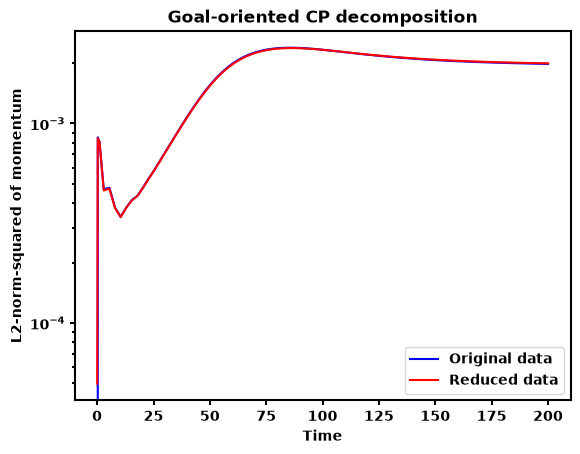

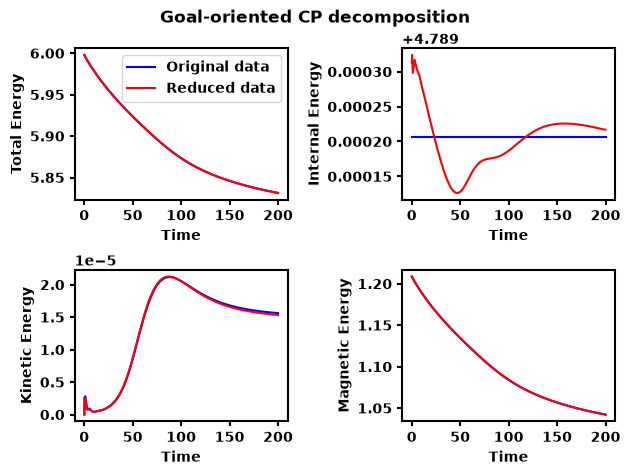

In [10]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us1,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Goal-oriented CP decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('mom-final.png')

    fig,axs = goals.plot_energies(X,us1,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Goal-oriented CP decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('energy-final.png')